# Kink injection-recovery: `*_kink0` folders (Spartan run)

Candidate r = Pinte+2025 Table 2 r_planet (`rkink`); az = Figure 5 blue dot. Rep and `1sigma` folders not included yet.

In [1]:
import glob, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as disk

base = r"D:\CPD_MPIA\HPC_kink_spartan"
runs = {"AA_Tau": 2, "J1615": 2, "J1842": 0, "LkCa_15": 2, "SY_Cha": 1}   # target: gap label used in the file names

# decisions!  How many pixels tolerated?  How many x astrometry RMS?  (same as assess_recovery.ipynb)
npix_tol, ast_tol = 2, 2

## Injection zone and search region on the continuum image

The image is the robust −0.5 continuum, the same robust value the pipeline images with. Each quantity is read from the folder's own scripts, so the plot matches the run.

- **Injection zone (lime):** from `*_injectloop.py`, CANDIDATE_R ± 1 beam (BEAM_FWHM) and CANDIDATE_AZ ± 7.5°.
- **Search region (cyan, dashed):** from `recover_loop.py`, CANDIDATE_R ± 2 beams and CANDIDATE_AZ ± (7.5° + beam/R in degrees).

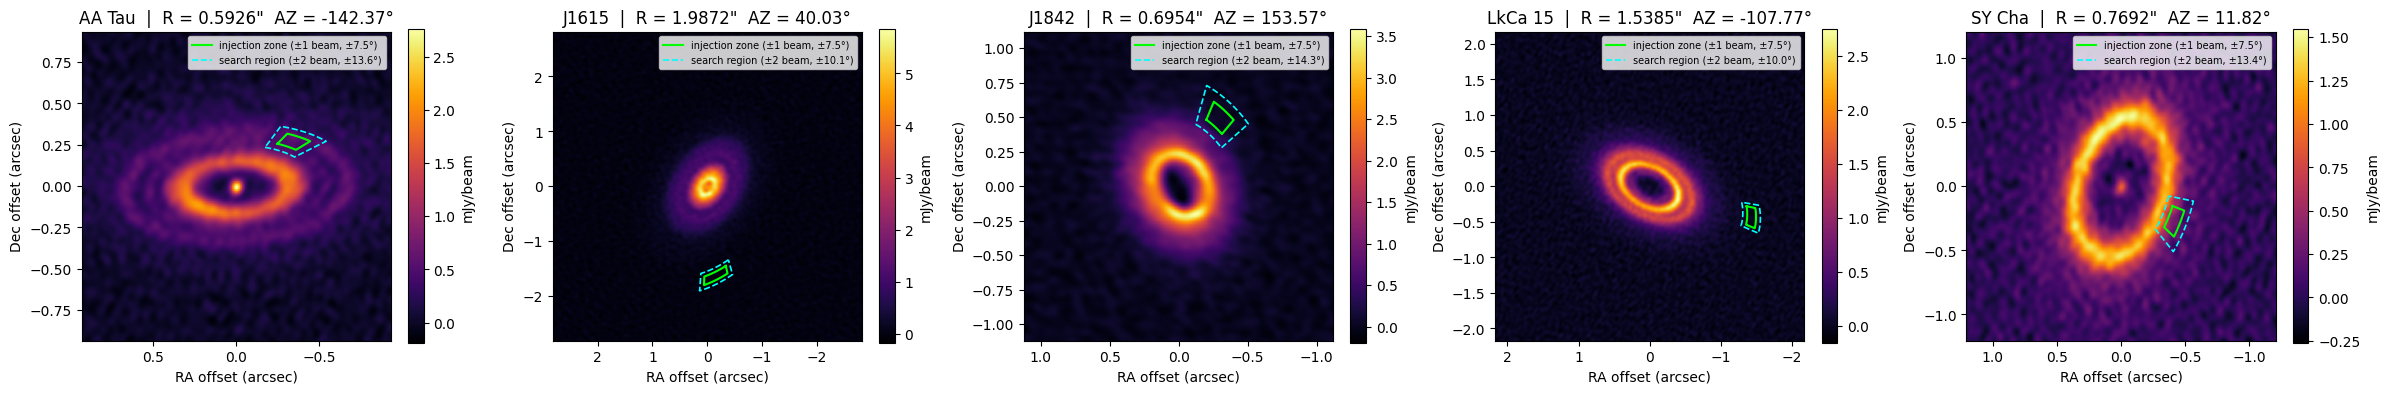

In [2]:
import re

def wedge(ax, r_lo, r_hi, az_lo, az_hi, PAr, inclr, **kw):
    # outline of a disk-plane (r, az) wedge on the sky, same projection as the recovery criterion above
    az = np.radians(np.r_[np.linspace(az_lo, az_hi, 50), np.linspace(az_hi, az_lo, 50), az_lo])
    r = np.r_[np.full(50, r_lo), np.full(50, r_hi), r_lo]
    ax.plot(r * np.sin(az) * np.sin(PAr) + r * np.cos(az) * np.cos(inclr) * np.cos(PAr),
            r * np.sin(az) * np.cos(PAr) - r * np.cos(az) * np.cos(inclr) * np.sin(PAr), **kw)

fig, axs = plt.subplots(1, 5, figsize=(24, 5))
for ax, target in zip(axs, runs):
    src = open(glob.glob(f"{base}/{target}_kink0/*_injectloop.py")[0]).read()
    R = float(re.search(r"^CANDIDATE_R\s*=\s*([-\d.]+)", src, re.M).group(1))
    AZ = float(re.search(r"^CANDIDATE_AZ\s*=\s*([-\d.]+)", src, re.M).group(1))
    BEAM = float(re.search(r"^BEAM_FWHM\s*=\s*([-\d.]+)", src, re.M).group(1))
    d = disk.disk[target]
    PAr, inclr = np.radians(d['PA']), np.radians(d['incl'])

    hdu = fits.open(rf"D:\exoALMA_disk_data\{target}\images_data_different_robust\{target}_continuum_data_robust-0.5.image.fits")
    img, hd = 1e3 * np.squeeze(hdu[0].data), hdu[0].header   # mJy/beam
    RAo = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx']
    DECo = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy']
    im = ax.imshow(img, origin='lower', cmap='inferno', extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
    fig.colorbar(im, ax=ax, fraction=0.046, label='mJy/beam')

    daz = 7.5 + np.degrees(BEAM / R)
    wedge(ax, R - BEAM, R + BEAM, AZ - 7.5, AZ + 7.5, PAr, inclr, color='lime', lw=1.5,
          label='injection zone (±1 beam, ±7.5°)')
    wedge(ax, R - 2 * BEAM, R + 2 * BEAM, AZ - daz, AZ + daz, PAr, inclr, color='cyan', lw=1.2, ls='--',
          label=f'search region (±2 beam, ±{daz:.1f}°)')
    zoom = 1.3 * (R + 2 * BEAM)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.set_title(f"{target.replace('_', ' ')}  |  R = {R}\"  AZ = {AZ}°")
    ax.set_xlabel('RA offset (arcsec)')
    ax.set_ylabel('Dec offset (arcsec)')
    ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

### AA Tau zoom: local residuals around the injection zone


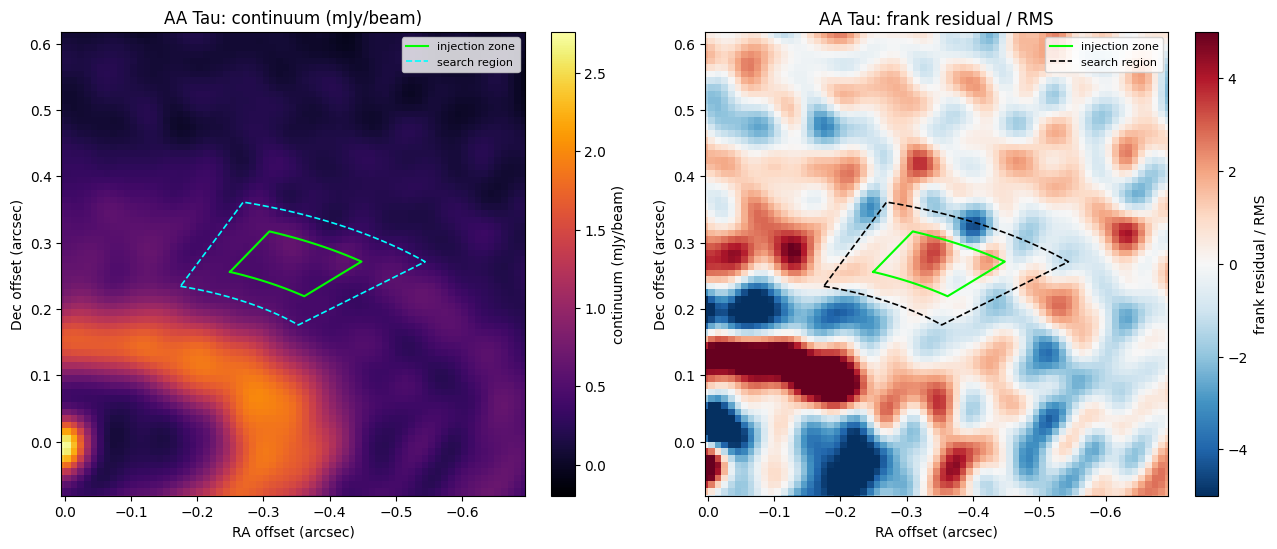

In [3]:
# AA Tau zoom: continuum | frank residual (robust -0.5, in units of the image RMS), centred on the injection zone
target = 'AA_Tau'
src = open(glob.glob(f"{base}/{target}_kink0/*_injectloop.py")[0]).read()
R = float(re.search(r"^CANDIDATE_R\s*=\s*([-\d.]+)", src, re.M).group(1))
AZ = float(re.search(r"^CANDIDATE_AZ\s*=\s*([-\d.]+)", src, re.M).group(1))
BEAM = float(re.search(r"^BEAM_FWHM\s*=\s*([-\d.]+)", src, re.M).group(1))
d = disk.disk[target]
PAr, inclr = np.radians(d['PA']), np.radians(d['incl'])
daz = 7.5 + np.degrees(BEAM / R)

# sky position of the candidate, used as the zoom centre
azr = np.radians(AZ)
xc = R * np.sin(azr) * np.sin(PAr) + R * np.cos(azr) * np.cos(inclr) * np.cos(PAr)
yc = R * np.sin(azr) * np.cos(PAr) - R * np.cos(azr) * np.cos(inclr) * np.sin(PAr)
half = 0.35   # arcsec

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, fn, title in [(axs[0], rf"D:\exoALMA_disk_data\{target}\images_data_different_robust\{target}_continuum_data_robust-0.5.image.fits", 'continuum (mJy/beam)'),
                      (axs[1], rf"D:\exoALMA_disk_data\{target}\images_frank_residuals_different_robust\{target}_continuum_resid_robust-0.5.image.fits", 'frank residual / RMS')]:
    hdu = fits.open(fn)
    img, hd = np.squeeze(hdu[0].data), hdu[0].header
    RAo = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx']
    DECo = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy']
    ext = [RAo[0], RAo[-1], DECo[0], DECo[-1]]
    if 'resid' in fn:
        im = ax.imshow(1e6 * img / d['RMS'], origin='lower', cmap='RdBu_r', vmin=-5, vmax=5, extent=ext)
    else:
        im = ax.imshow(1e3 * img, origin='lower', cmap='inferno', extent=ext)
    fig.colorbar(im, ax=ax, fraction=0.046, label=title)
    wedge(ax, R - BEAM, R + BEAM, AZ - 7.5, AZ + 7.5, PAr, inclr, color='lime', lw=1.5, label='injection zone')
    wedge(ax, R - 2 * BEAM, R + 2 * BEAM, AZ - daz, AZ + daz, PAr, inclr, color='k' if 'resid' in fn else 'cyan',
          lw=1.2, ls='--', label='search region')
    ax.set_xlim(xc + half, xc - half)
    ax.set_ylim(yc - half, yc + half)
    ax.set_xlabel('RA offset (arcsec)')
    ax.set_ylabel('Dec offset (arcsec)')
    ax.set_title(f"AA Tau: {title}")
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## HD 135344B candidates: frank residual around the injection and search regions

This is the robust −0.5 frank residual of the real data, in units of the image RMS (no injections). The panels are centred on the disk and wide enough to show the inner disk and the search region. R, AZ and BEAM_FWHM are read from each candidate's `*_injectloop.py`. Injection zone: R ± 1 beam, AZ ± beam/R. Search region: R ± 2 beams, AZ ± 2·beam/R. The kinks have their own paper figure below.

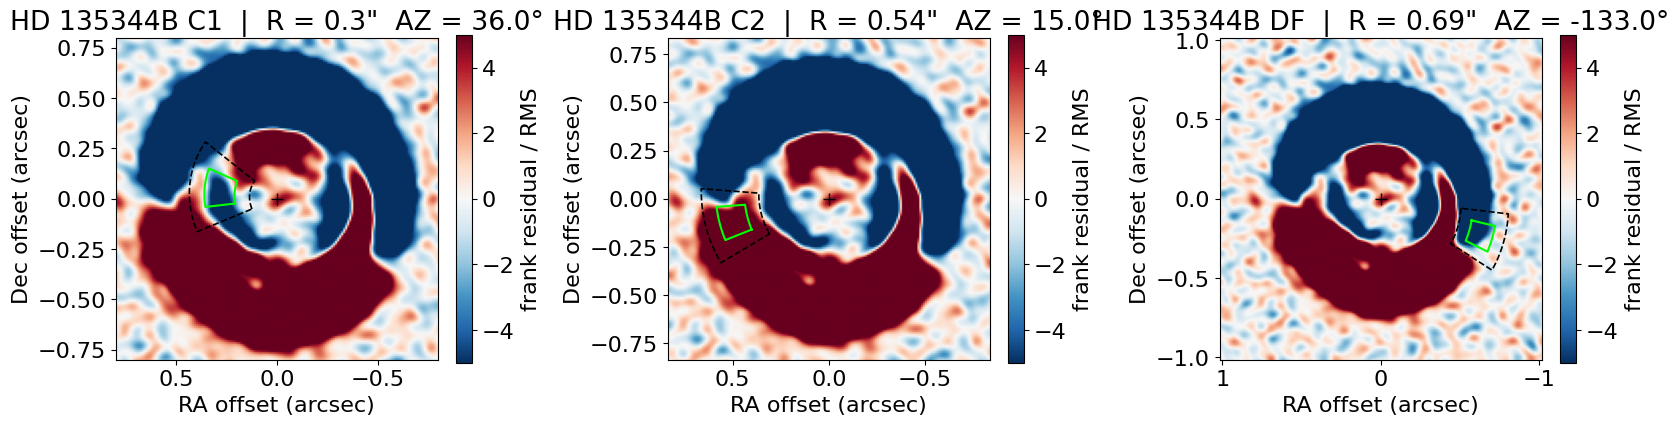

In [4]:
groups = [('HD 135344B candidates', [(f'HD 135344B {c}', 'HD_135344B', rf"D:\CPD_MPIA\HPC_eqC1_gap\gap\HD_135344B_{c}", 'point') for c in ['C1', 'C2', 'DF']])]


plt.rcParams.update({'font.size': 16})

for gname, cands in groups:
    fig, axs = plt.subplots(1, len(cands), figsize=(5.6 * len(cands), 5.2))
    for ax, (label, target, folder, kind) in zip(axs.flat, cands):
        src = open(glob.glob(folder + "/*_injectloop.py")[0]).read()
        R = float(re.search(r"^CANDIDATE_R\s*=\s*([-\d.]+)", src, re.M).group(1))
        AZ = float(re.search(r"^CANDIDATE_AZ\s*=\s*([-\d.]+)", src, re.M).group(1))
        BEAM = float(re.search(r"^BEAM_FWHM\s*=\s*([-\d.]+)", src, re.M).group(1))
        inj_daz, search_daz = np.degrees(BEAM / R), np.degrees(2 * BEAM / R)
        d = disk.disk[target]
        PAr, inclr = np.radians(d['PA']), np.radians(d['incl'])

        hdu = fits.open(rf"D:\exoALMA_disk_data\{target}\images_frank_residuals_different_robust\{target}_continuum_resid_robust-0.5.image.fits")
        img, hd = np.squeeze(hdu[0].data), hdu[0].header
        RAo = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx']
        DECo = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy']
        im = ax.imshow(1e6 * img / d['RMS'], origin='lower', cmap='RdBu_r', vmin=-5, vmax=5,
                       extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
        fig.colorbar(im, ax=ax, fraction=0.046, label='frank residual / RMS')
        wedge(ax, R - BEAM, R + BEAM, AZ - inj_daz, AZ + inj_daz, PAr, inclr, color='lime', lw=1.5,
              label=f'injection (±1 beam, ±{inj_daz:.1f}°)')
        wedge(ax, R - 2 * BEAM, R + 2 * BEAM, AZ - search_daz, AZ + search_daz, PAr, inclr, color='k', lw=1.2, ls='--',
              label=f'search (±2 beam, ±{search_daz:.1f}°)')
        # centred on the disk, wide enough for the inner disk and the search region
        ax.plot(0, 0, '+', color='k', ms=8)
        half = max(1.2 * (R + 2 * BEAM), 0.8)
        ax.set_xlim(half, -half)
        ax.set_ylim(-half, half)
        ax.set_title(f'{label}  |  R = {R}"  AZ = {AZ}°')
        ax.set_xlabel('RA offset (arcsec)')
        ax.set_ylabel('Dec offset (arcsec)')
        #ax.legend(fontsize=7, loc='upper right')
    #fig.suptitle(f'frank residual (robust -0.5, no injections): {gname}')
    plt.tight_layout()
    plt.show()

## Kinks: frank residual around each candidate (paper figure)

This is the robust −0.5 frank residual of the real data in units of the image RMS (no injections). Each panel is centred on the kink candidate, with ΔRA and ΔDec measured from the candidate and the same ±0.7″ range in every panel.

- **Injection zone (lime):** R ± 1 beam, AZ ± 7.5°.
- **Search region (black dashed):** R ± 2 beams, AZ ± (7.5° + beam/R).
- **Ellipse:** the beam.
- **Labels:** r = R × distance, and φ = the disk-plane azimuth used by the pipeline (`CANDIDATE_AZ`).

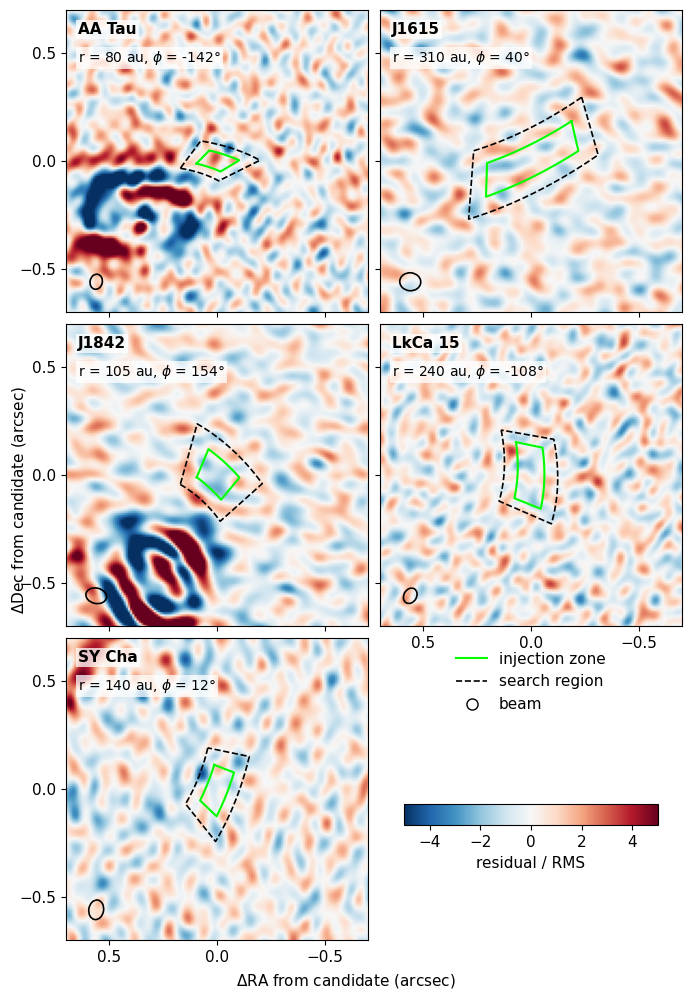

In [5]:
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

FS = 11       # font size for this figure (7 in wide = full journal page width)
half = 0.7    # arcsec, panel half-width around each candidate

with plt.rc_context({'font.size': FS}):
    fig, axs = plt.subplots(3, 2, figsize=(7, 10), sharex=True, sharey=True)
    for ax, target in zip(axs.flat, runs):
        src = open(glob.glob(f"{base}/{target}_kink0/*_injectloop.py")[0]).read()
        R = float(re.search(r"^CANDIDATE_R\s*=\s*([-\d.]+)", src, re.M).group(1))
        AZ = float(re.search(r"^CANDIDATE_AZ\s*=\s*([-\d.]+)", src, re.M).group(1))
        BEAM = float(re.search(r"^BEAM_FWHM\s*=\s*([-\d.]+)", src, re.M).group(1))
        d = disk.disk[target]
        PAr, inclr = np.radians(d['PA']), np.radians(d['incl'])
        azr = np.radians(AZ)
        xc = R * np.sin(azr) * np.sin(PAr) + R * np.cos(azr) * np.cos(inclr) * np.cos(PAr)   # candidate, sky offset from the star
        yc = R * np.sin(azr) * np.cos(PAr) - R * np.cos(azr) * np.cos(inclr) * np.sin(PAr)

        hdu = fits.open(rf"D:\exoALMA_disk_data\{target}\images_frank_residuals_different_robust\{target}_continuum_resid_robust-0.5.image.fits")
        img, hd = np.squeeze(hdu[0].data), hdu[0].header
        RAo = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx'] - xc   # relative to the candidate
        DECo = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy'] - yc
        im = ax.imshow(1e6 * img / d['RMS'], origin='lower', cmap='RdBu_r', vmin=-5, vmax=5,
                       extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])

        # zones: wedge() draws in star-centred coordinates, so shift the axes data by the candidate offset
        for r_hw, az_hw, kw in [(BEAM, 7.5, dict(color='lime', lw=1.5)),
                                (2 * BEAM, 7.5 + np.degrees(BEAM / R), dict(color='k', lw=1.2, ls='--'))]:
            az = np.radians(np.r_[np.linspace(AZ - az_hw, AZ + az_hw, 50), np.linspace(AZ + az_hw, AZ - az_hw, 50), AZ - az_hw])
            r = np.r_[np.full(50, R - r_hw), np.full(50, R + r_hw), R - r_hw]
            ax.plot(r * np.sin(az) * np.sin(PAr) + r * np.cos(az) * np.cos(inclr) * np.cos(PAr) - xc,
                    r * np.sin(az) * np.cos(PAr) - r * np.cos(az) * np.cos(inclr) * np.sin(PAr) - yc, **kw)

        # beam (lower-left corner; RA axis is flipped, so lower left = +dRA, -dDec)
        ax.add_patch(Ellipse((0.8 * half, -0.8 * half), 3600 * hd['BMIN'], 3600 * hd['BMAJ'], angle=-hd['BPA'],
                             facecolor='none', edgecolor='k', lw=1.2))
        lab = dict(transform=ax.transAxes, ha='left', va='top', color='k', bbox=dict(fc='white', alpha=0.75, ec='none', pad=1.5))
        ax.text(0.04, 0.96, target.replace('_', ' '), fontweight='bold', **lab)
        ax.text(0.04, 0.87, rf"r = {R * d['distance']:.0f} au, $\phi$ = {AZ:.0f}°", fontsize=FS - 1, **lab)

        ax.set_xlim(half, -half)
        ax.set_ylim(-half, half)
        ax.set_xticks([0.5, 0, -0.5])
        ax.set_yticks([-0.5, 0, 0.5])
        ax.set_aspect('equal')

    # empty slot: shared legend + colorbar
    leg_ax = axs[2, 1]
    leg_ax.axis('off')
    axs[1, 1].tick_params(labelbottom=True)   # LkCa 15 sits above the empty slot, so it keeps its x tick labels
    leg_ax.legend(handles=[Line2D([], [], color='lime', lw=1.5, label='injection zone'),
                           Line2D([], [], color='k', lw=1.2, ls='--', label='search region'),
                           Line2D([], [], color='k', lw=0, marker='o', mfc='none', ms=8, label='beam')],
                  loc='upper center', frameon=False)
    fig.colorbar(im, cax=leg_ax.inset_axes([0.08, 0.38, 0.84, 0.07]), orientation='horizontal', label='residual / RMS')
    fig.supxlabel(r'$\Delta$RA from candidate (arcsec)', fontsize=FS)
    fig.supylabel(r'$\Delta$Dec from candidate (arcsec)', fontsize=FS)
    fig.subplots_adjust(left=0.1, right=0.98, bottom=0.06, top=0.99, wspace=0.04, hspace=0.04)
    plt.show()

### HD 135344B: all three candidates on one view

Same layout as the overview in `injrev_sum_plot.ipynb`, but on the frank residual of the real data (robust −0.5, no injections), in units of the image RMS. Lime = injection zone, black dashed = search region.


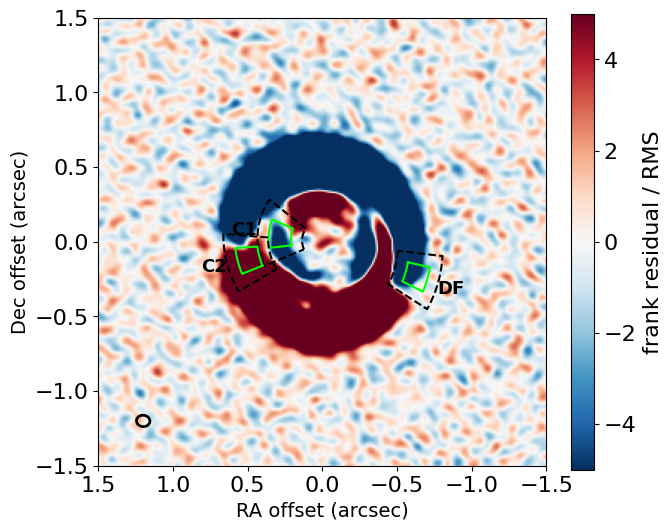

In [6]:
from matplotlib.patches import Ellipse

target = 'HD_135344B'
d = disk.disk[target]
PAr, inclr = np.radians(d['PA']), np.radians(d['incl'])
hdu = fits.open(rf"D:\exoALMA_disk_data\{target}\images_frank_residuals_different_robust\{target}_continuum_resid_robust-0.5.image.fits")
img, hd = 1e6 * np.squeeze(hdu[0].data) / d['RMS'], hdu[0].header   # in units of the image RMS
RAo = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx']
DECo = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy']

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-5, vmax=5, extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
plt.colorbar(im, ax=ax, fraction=0.046, label='frank residual / RMS')

for c in ['C1', 'C2', 'DF']:
    src = open(glob.glob(rf"D:\CPD_MPIA\HPC_eqC1_gap\gap\HD_135344B_{c}\*_injectloop.py")[0]).read()
    R = float(re.search(r"^CANDIDATE_R\s*=\s*([-\d.]+)", src, re.M).group(1))
    AZ = float(re.search(r"^CANDIDATE_AZ\s*=\s*([-\d.]+)", src, re.M).group(1))
    BEAM = float(re.search(r"^BEAM_FWHM\s*=\s*([-\d.]+)", src, re.M).group(1))
    wedge(ax, R - BEAM, R + BEAM, AZ - np.degrees(BEAM / R), AZ + np.degrees(BEAM / R), PAr, inclr, color='lime', lw=1.5)
    wedge(ax, R - 2 * BEAM, R + 2 * BEAM, AZ - np.degrees(2 * BEAM / R), AZ + np.degrees(2 * BEAM / R), PAr, inclr,
          color='k', ls='--', lw=1.5)
    rl, azl = R + 3.2 * BEAM, np.radians(AZ)   # label just outside the search region
    ax.text(rl * np.sin(azl) * np.sin(PAr) + rl * np.cos(azl) * np.cos(inclr) * np.cos(PAr),
            rl * np.sin(azl) * np.cos(PAr) - rl * np.cos(azl) * np.cos(inclr) * np.sin(PAr),
            c, color='k', fontsize=13, fontweight='bold', ha='center', va='center')

# beam ellipse, lower-left corner (RA axis is flipped, so lower left = +RA, -Dec)
ax.add_patch(Ellipse((1.2, -1.2), 3600 * hd['BMIN'], 3600 * hd['BMAJ'], angle=-hd['BPA'],
                     facecolor='none', edgecolor='k', lw=2, zorder=6))
ax.set_xlim(1.5, -1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('RA offset (arcsec)', fontsize=14)
ax.set_ylabel('Dec offset (arcsec)', fontsize=14)
fig.tight_layout()
plt.show()

## Recovery fraction: uv-fixed kink runs, in the style of `injrev_sum_plot.ipynb`

The plot uses criterion B (Cycle 7 Handbook, 2σ with a 2-pixel floor), the same criterion as `frec_B` in the `*_rprofs` files. Error bars are sqrt(n)/N, and dotted lines mark F50.

The uv-fixed runs are the `{target}_kink0_uvfix` folder plus the `{target}_kink0_rep*` folders, which were run with the uv fix. They are concatenated and saved as `{target}_kink0_uvfix/recoveries/{target}_gap{N}_recoveries.combined.txt`, and rep folders are picked up automatically once their recoveries are synced. D is the kink radius in au (`rkink` × distance).

AA_Tau   10 run(s)  N/bin =  500  D = 80 au  F50_B = 43.0 microJy
SY_Cha   10 run(s)  N/bin =  500  D = 140 au  F50_B = 150.4 microJy


J1615    10 run(s)  N/bin =  500  D = 310 au  F50_B = 84.5 microJy
LkCa_15  10 run(s)  N/bin =  500  D = 240 au  F50_B = 94.8 microJy


J1842    10 run(s)  N/bin =  500  D = 105 au  F50_B = 137.5 microJy


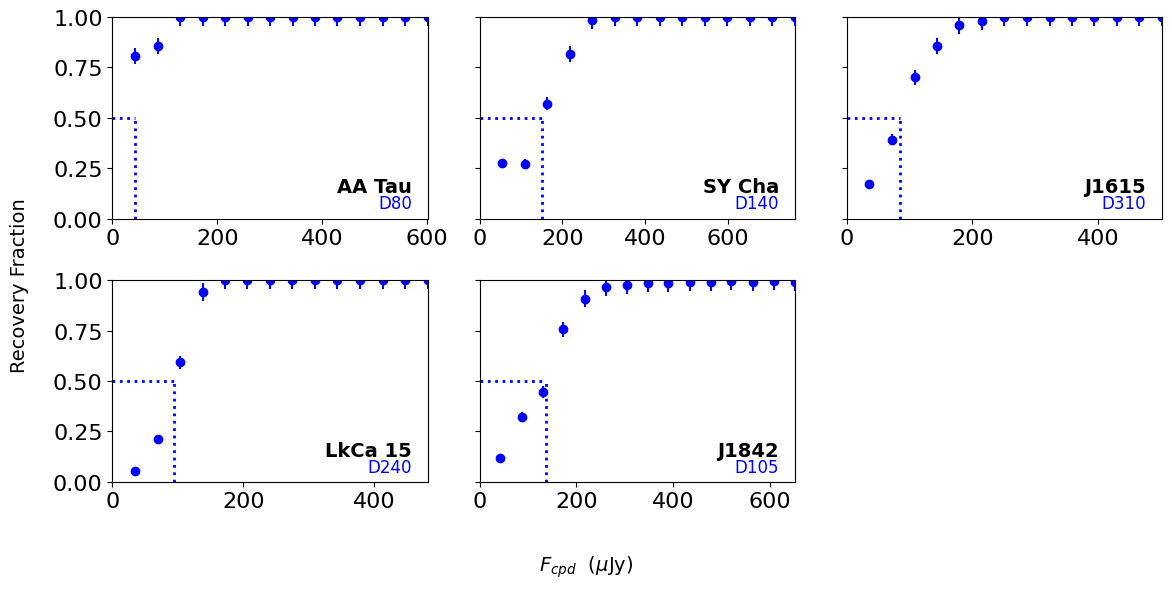

In [7]:
def curves(dat, target, folder):
    # recovery fraction vs injected flux for criteria A and B (same as assess_recovery.ipynb)
    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = dat.T
    azir = np.radians(azi)
    inclr, PAr = np.radians(disk.disk[target]['incl']), np.radians(disk.disk[target]['PA'])
    xi = ri * np.sin(azir) * np.sin(PAr) + ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
    yi = ri * np.sin(azir) * np.cos(PAr) - ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)
    d_ir = np.hypot(xi - xr, yi - yr)
    hd = fits.getheader(sorted(glob.glob(folder + '/recoveries/*.resid.fits'))[0])
    beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])
    pix_size = np.abs(3600 * hd['CDELT2'])
    vdat = np.load(rf"D:\exoALMA_disk_data\measurement_set_spavg\npz\{target}_time_ave_continuum_spavg_lambda.vis.npz")
    freq, wave = hd['CRVAL3'], 2.99792e5 / hd['CRVAL3']   # Hz, km
    Bmax_km = (wave * np.hypot(vdat['u'], vdat['v'])).max()
    sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
    Fcpd = np.unique(Fi)
    N = np.array([np.sum(Fi == F) for F in Fcpd])
    fA = np.array([np.mean((d_ir <= np.maximum(ast_tol * sigma_A, npix_tol * pix_size))[Fi == F]) for F in Fcpd])
    fB = np.array([np.mean((d_ir <= np.maximum(ast_tol * sigma_B, npix_tol * pix_size))[Fi == F]) for F in Fcpd])
    nB = np.array([np.sum((d_ir <= np.maximum(ast_tol * sigma_B, npix_tol * pix_size))[Fi == F]) for F in Fcpd])
    return Fcpd, N, fA, fB, nB

def F50(Fcpd, fr):
    # first flux where the recovery fraction reaches 0.5, linearly interpolated
    i = np.argmax(fr >= 0.5)
    return np.nan if fr[i] < 0.5 else (Fcpd[0] if i == 0 else np.interp(0.5, fr[i - 1:i + 1], Fcpd[i - 1:i + 1]))

Kink = [("AA_Tau", 2), ("SY_Cha", 1), ("J1615", 2), ("LkCa_15", 2), ("J1842", 0)]   # same order as injrev_sum_plot.ipynb

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, (target, gap) in zip(axes.flat, Kink):
    name = f"{target}_gap{gap}_recoveries"
    # uv-fixed runs: the uvfix folder plus the kink0_rep* folders (the reps were run with the uv fix)
    uv_files = sorted(glob.glob(f"{base}/{target}_kink0_uvfix*/recoveries/{name}.0.txt") +
                      glob.glob(f"{base}/{target}_kink0_rep[0-9]*/recoveries/{name}.0.txt"))
    uvfix = np.vstack([np.loadtxt(u) for u in uv_files])
    np.savetxt(f"{base}/{target}_kink0_uvfix/recoveries/{name}.combined.txt", uvfix, fmt='%g')

    Fcpd, N, fA, frec_B, nB = curves(uvfix, target, f"{base}/{target}_kink0_uvfix")
    efrec_B = np.sqrt(nB) / N   # same error convention as the *_rprofs files used in injrev_sum_plot.ipynb
    D_au = disk.disk[target]["rkink"][0] * disk.disk[target]["distance"]
    ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker="o", color="b", ls="none", capsize=0.0, elinewidth=1.5)
    F50B = F50(Fcpd, frec_B)
    ax.hlines(0.5, 0, F50B, color="b", ls=":", lw=2)
    ax.vlines(F50B, 0, 0.5, color="b", ls=":", lw=2)
    ax.text(0.95, 0.13, target.replace("_", " "), transform=ax.transAxes, ha="right", fontsize=14, fontweight="bold")
    ax.text(0.95, 0.05, f"D{D_au:.0f}", color="b", transform=ax.transAxes, ha="right", fontsize=12)
    ax.set_xlim(0, np.max(Fcpd))
    ax.set_ylim(0, 1)
    print(f"{target:8s} {len(uv_files):2d} run(s)  N/bin = {N[0]:4d}  D = {D_au:.0f} au  F50_B = {F50B:.1f} microJy")

for ax in axes.flat[len(Kink):]:
    ax.axis("off")
fig.supxlabel(r"$F_{cpd}$  ($\mu$Jy)", fontsize=14)
fig.supylabel("Recovery Fraction", fontsize=14)
fig.tight_layout()
plt.show()

Good overall, just that for AA Tau, it reaches 75 percent of recovery even at injection of 1 rms level, because the injection box is too small and there is a local residual with 3.5 rms strong 